In [ ]:
pip install kagglehub pandas matplotlib seaborn

In [1]:
import kagglehub
import shutil
import os

# Download latest version
path = kagglehub.dataset_download("iammustafatz/diabetes-prediction-dataset")

# Copio el archivo descargado a la carpeta dataset
dest = os.path.join(os.getcwd(), "dataset")
os.makedirs(dest, exist_ok=True)
for f in os.listdir(path):
    shutil.copy2(os.path.join(path, f), os.path.join(dest, f))

print("Path al dataset:", dest)

f:\Facu-temp\Mg-Datos\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 734k/734k [00:00<00:00, 955kB/s]

Extracting files...
Path al dataset: f:\Facu-temp\Mg-Datos\automatizacion-test\dataset


In [1]:
from pathlib import Path
import pandas as pd
diabetes = pd.read_csv("dataset/diabetes_prediction_dataset.csv")

## Análisis Exploratorio de Datos (EDA)

In [16]:
diabetes.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [17]:
diabetes.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 6.9 MB


In [6]:
diabetes.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


## Calidad de datos

Vemos si hay nulos

In [13]:
nulos=diabetes.isnull().sum()
nulos_pct = nulos / len(diabetes) * 100
nulos_df = pd.DataFrame({"nulos": nulos, "nulos_pct": nulos_pct})
print('Datos nulos por columna:')
print(nulos_df[nulos_df["nulos"] > 0])
if nulos_df["nulos"].sum() == 0:
    print("No hay datos nulos en el dataset.")

Datos nulos por columna:
Empty DataFrame
Columns: [nulos, nulos_pct]
Index: []
No hay datos nulos en el dataset.


Vemos si hay registros duplicados

In [18]:
duplicados = diabetes.duplicated().sum()
print(f"Datos duplicados: {duplicados} ({duplicados / len(diabetes) * 100:.2f}%)")

Datos duplicados: 3854 (3.85%)


Hay, los quitamos, pueden traer inconvenientes si caen el mismo conjunto de split

In [2]:
diabetes.drop_duplicates(inplace=True, ignore_index=True)
diabetes.shape

(96146, 9)

Volvemos a describir

In [3]:
diabetes.describe().T

,count,mean,std,min,25%,50%,75%,max
age,96146.0,41.794326,22.462948,0.08,24.0,43.00,59.00,80.00
hypertension,96146.0,0.077601,0.267544,0.00,0.0,0.00,0.00,1.00
heart_disease,96146.0,0.040803,0.197833,0.00,0.0,0.00,0.00,1.00
bmi,96146.0,27.321461,6.767716,10.01,23.4,27.32,29.86,95.69
HbA1c_level,96146.0,5.532609,1.073232,3.50,4.8,5.80,6.20,9.00
blood_glucose_level,96146.0,138.218231,40.909771,80.00,100.0,140.00,159.00,300.00
diabetes,96146.0,0.088220,0.283616,0.00,0.0,0.00,0.00,1.00


Valores únicos por columna

In [27]:
for col in diabetes.columns:
    print(f"Columna {col}: {diabetes[col].nunique()} valores únicos")
    if diabetes[col].nunique() < 10:
        print(f"Valores: {diabetes[col].unique()}")

Columna gender: 3 valores únicos
Valores: <StringArray>
['Female', 'Male', 'Other']
Length: 3, dtype: str
Columna age: 102 valores únicos
Columna hypertension: 2 valores únicos
Valores: [0 1]
Columna heart_disease: 2 valores únicos
Valores: [1 0]
Columna smoking_history: 6 valores únicos
Valores: <StringArray>
['never', 'No Info', 'current', 'former', 'ever', 'not current']
Length: 6, dtype: str
Columna bmi: 4247 valores únicos
Columna HbA1c_level: 18 valores únicos
Columna blood_glucose_level: 18 valores únicos
Columna diabetes: 2 valores únicos
Valores: [0 1]


In [36]:
print(diabetes["smoking_history"].value_counts())
print(f"'No Info' en smoking_history: {(diabetes['smoking_history'] == 'No Info').sum()} ({(diabetes['smoking_history'] == 'No Info').mean() * 100:.2f}%)")

smoking_history
never          34398
No Info        32887
former          9299
current         9197
not current     6367
ever            3998
Name: count, dtype: int64
'No Info' en smoking_history: 32887 (34.21%)


Investigamos también Género

In [37]:
diabetes['gender'].value_counts()

gender
Female    56161
Male      39967
Other        18
Name: count, dtype: int64

## Gráficos univariables

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

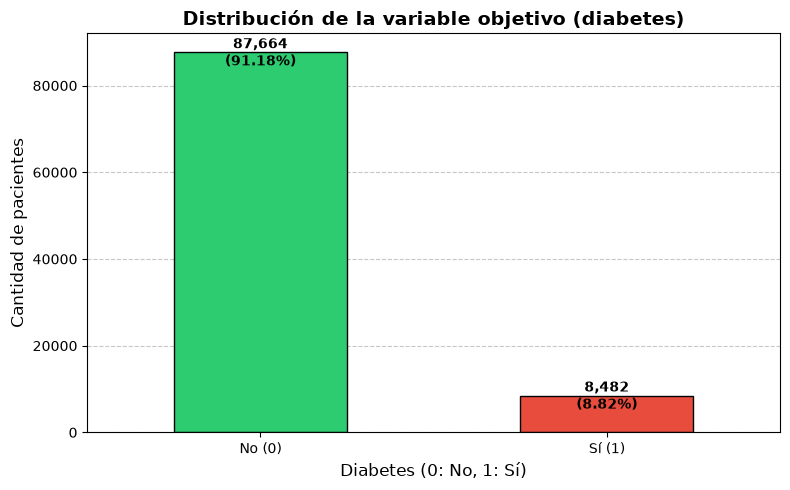

In [57]:
# Visualización de la distribución de la variable objetivo
fig, ax = plt.subplots(figsize=(8, 5))
color = ['#2ecc71', '#e74c3c']
diabetes['diabetes'].value_counts().plot(kind='bar', color=color, edgecolor='black', ax=ax)
ax.set_title('Distribución de la variable objetivo (diabetes)', fontsize=14, fontweight='bold')
ax.set_xlabel('Diabetes (0: No, 1: Sí)', fontsize=12)
ax.set_ylabel('Cantidad de pacientes', fontsize=12)
ax.set_xticklabels(['No (0)', 'Sí (1)'], rotation=0)

for i, v in enumerate(diabetes['diabetes'].value_counts()):
    ax.text(i, v -3000, f'{v:,}\n({v/len(diabetes)*100:.2f}%)', color='black', ha='center', fontweight='bold')
    
ax.set_axisbelow(True)
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Diabetes (variable objetivo):** fuertemente desbalanceada: solo 8.82% de casos positivos (8482 de 96146). Un modelo trivial que predijera siempre 0 acertaría el 91.18%, por lo que conviene evaluar con recall, F1 o PR-AUC y considerar técnicas de balanceo.

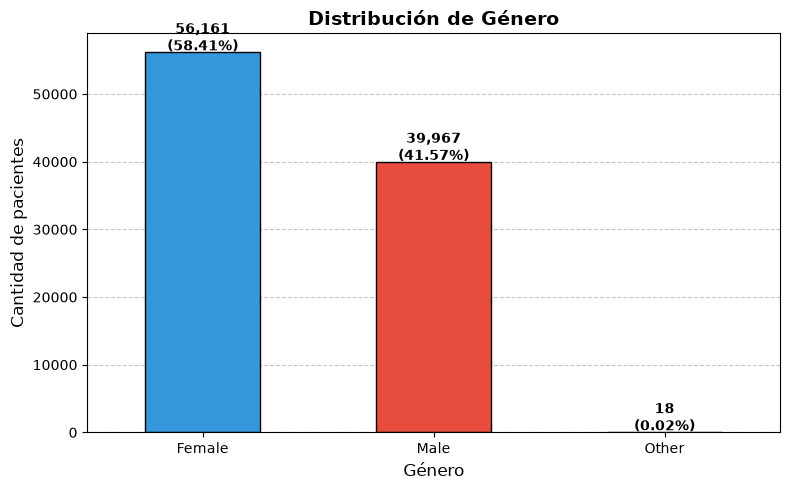

In [58]:
fig, ax = plt.subplots(figsize=(8, 5))
color =['#3498db', '#e74c3c', '#95a5a6']
diabetes['gender'].value_counts().plot(kind='bar', color=color, edgecolor='black', ax=ax)
ax.set_title('Distribución de Género', fontsize=14, fontweight='bold')
ax.set_xlabel('Género', fontsize=12)
ax.set_ylabel('Cantidad de pacientes', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

for i, v in enumerate(diabetes['gender'].value_counts()):
    ax.text(i, v + 300, f'{v:,}\n({v/len(diabetes)*100:.2f}%)', color='black', ha='center', fontweight='bold')
    
ax.set_axisbelow(True)
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Género:** muestra levemente desbalanceada: 58.41% mujeres, 41.57% varones y apenas 18 registros (0.02%) en la categoría *Other*. Más adelante tomaremos una decisión sobre la categoría *Other*, pero en principio se podría decir que no hay sesgo fuerte de género en el dataset.

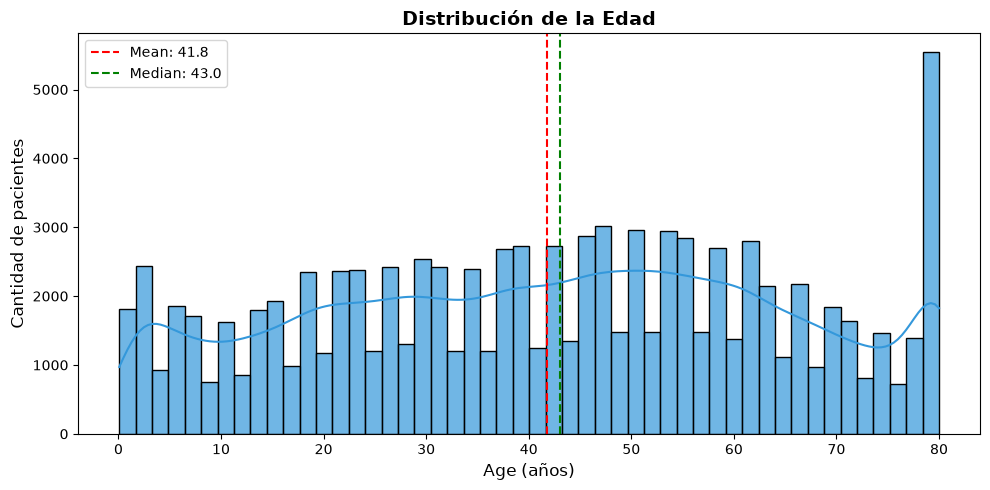

In [60]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=diabetes, x='age', bins=50, kde=True, color='#3498db', edgecolor='black', alpha=0.7, ax=ax)
ax.set_title('Distribución de la Edad', fontsize=14, fontweight='bold')
ax.set_xlabel('Age (años)', fontsize=12)
ax.set_ylabel('Cantidad de pacientes', fontsize=12)
ax.axvline(diabetes['age'].mean(), color='red', linestyle='--', label=f'Mean: {diabetes["age"].mean():.1f}')
ax.axvline(diabetes['age'].median(), color='green', linestyle='--', label=f'Median: {diabetes["age"].median():.1f}')
ax.legend()
plt.tight_layout()

In [62]:
print(f'Asimetría de la distribución de la edad: {diabetes["age"].skew():.2f}')

Asimetría de la distribución de la edad: -0.06


age: 0 outliers (0.00%)


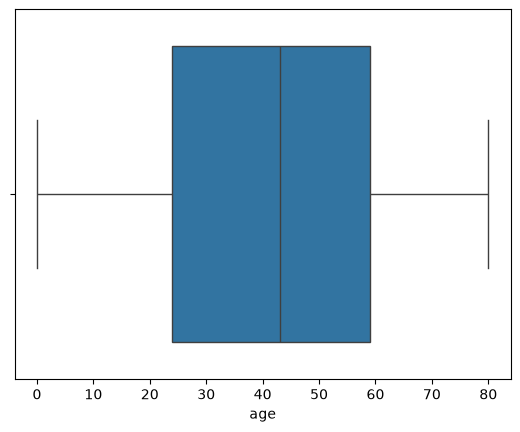

In [30]:
sns.boxplot(x=diabetes["age"])

# Reporte de outlier
Q1 = diabetes['age'].quantile(0.25)
Q3 = diabetes['age'].quantile(0.75)
IQR = Q3 - Q1
outliers = ((diabetes['age'] < Q1 - 1.5 * IQR) | (diabetes['age'] > Q3 + 1.5 * IQR)).sum()
print(f'age: {outliers} outliers ({outliers/len(diabetes)*100:.2f}%)')

plt.show()

**Edad:** abarca de 0.08 a 80 años con media ≈ 41.8 y distribución casi uniforme (asimetría ≈ 0): no hay una franja etaria dominante y el boxplot no muestra atípicos. Cerca del 17% son menores de 18 años.

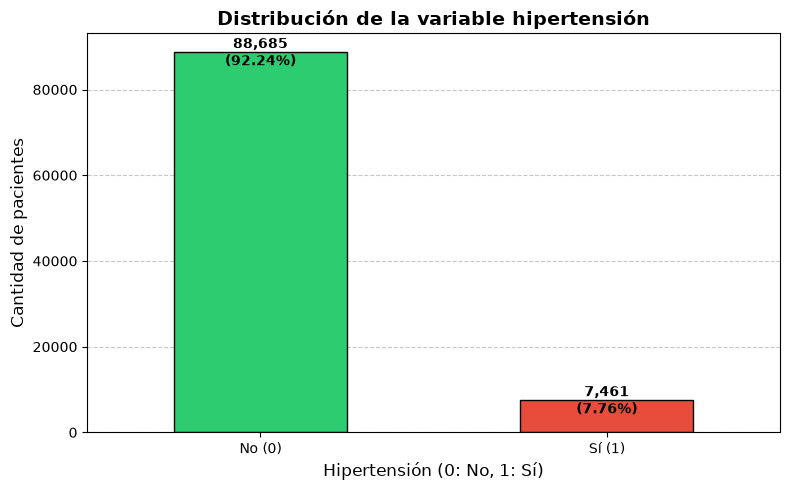

In [8]:
# Visualización de la distribución de la variable hipertension
fig, ax = plt.subplots(figsize=(8, 5))
color = ['#2ecc71', '#e74c3c']
diabetes['hypertension'].value_counts().plot(kind='bar', color=color, edgecolor='black', ax=ax)
ax.set_title('Distribución de la variable hipertensión', fontsize=14, fontweight='bold')
ax.set_xlabel('Hipertensión (0: No, 1: Sí)', fontsize=12)
ax.set_ylabel('Cantidad de pacientes', fontsize=12)
ax.set_xticklabels(['No (0)', 'Sí (1)'], rotation=0)

for i, v in enumerate(diabetes['hypertension'].value_counts()):
    ax.text(i, v -3000, f'{v:,}\n({v/len(diabetes)*100:.2f}%)', color='black', ha='center', fontweight='bold')
    
ax.set_axisbelow(True)
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Hipertensión:** variable binaria muy desbalanceada: solo el 7.76% de los registros (7461) presenta hipertensión. Es minoritaria pero clínicamente clave, ya que es un factor de riesgo clásico de diabetes.

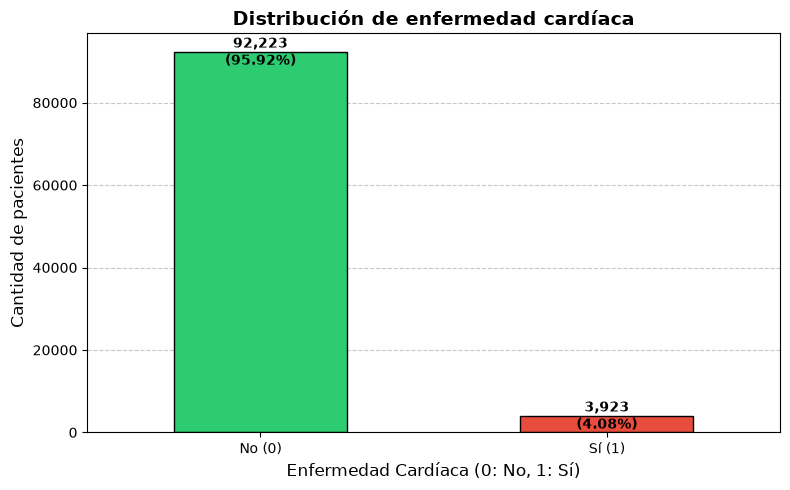

In [10]:
# Heart Disease Distribution
fig, ax = plt.subplots(figsize=(8, 5))
color = ['#2ecc71', '#e74c3c']
diabetes['heart_disease'].value_counts().plot(kind='bar', color=color, edgecolor='black', ax=ax)
ax.set_title('Distribución de enfermedad cardíaca', fontsize=14, fontweight='bold')
ax.set_xlabel('Enfermedad Cardíaca (0: No, 1: Sí)', fontsize=12)
ax.set_ylabel('Cantidad de pacientes', fontsize=12)
ax.set_xticklabels(['No (0)', 'Sí (1)'], rotation=0)

for i, v in enumerate(diabetes['heart_disease'].value_counts()):
    ax.text(i, v -3000, f'{v:,}\n({v/len(diabetes)*100:.2f}%)', color='black', ha='center', fontweight='bold')
    
ax.set_axisbelow(True)
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Enfermedad cardíaca:** aún más escasa que la hipertensión: solo 4.08% de positivos (3923 registros). El fuerte desbalance hacia 0 es esperable en población general, pero conviene prestar atención para modelar.

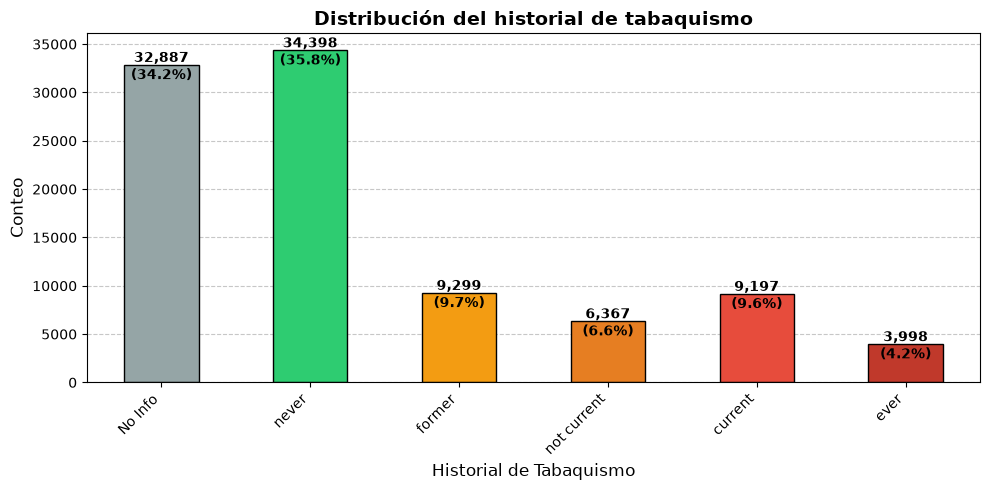

In [18]:
# Smoking history
fig, ax = plt.subplots(figsize=(10, 5))
smoking_counts = diabetes['smoking_history'].value_counts()
smoking_order = ['No Info', 'never', 'former', 'not current', 'current', 'ever']
smoking_counts = smoking_counts.reindex([x for x in smoking_order if x in smoking_counts.index])
colors = ['#95a5a6', '#2ecc71', '#f39c12', '#e67e22', '#e74c3c', '#c0392b']
smoking_counts.plot(kind='bar', color=colors[:len(smoking_counts)], edgecolor='black', ax=ax)
ax.set_title('Distribución del historial de tabaquismo', fontsize=14, fontweight='bold')
ax.set_xlabel('Historial de Tabaquismo', fontsize=12)
ax.set_ylabel('Conteo', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_axisbelow(True)
ax.grid(axis='y', linestyle='--', alpha=0.7)

for i, v in enumerate(smoking_counts):
    ax.text(i, v -1500, f'{v:,}\n({v/len(diabetes)*100:.1f}%)', color='black', ha='center', fontweight='bold')
plt.tight_layout()

**Historial de tabaquismo:** predominan *never* (35.78%) y *No Info* (34.21%): más de un tercio no declara datos, lo que introduce ruido en esta variable. Los fumadores actuales son ~9.6% y los ex fumadores ~9.7%.

bmi: 5354 outliers (5.57%)


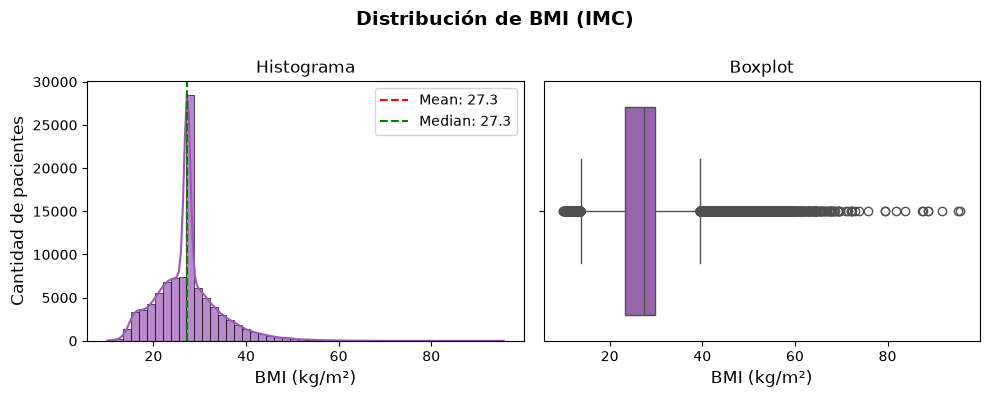

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Distribución de BMI (IMC)', fontsize=14, fontweight='bold')

sns.histplot(data=diabetes, x='bmi', bins=50, kde=True, color='#9b59b6', edgecolor='black', alpha=0.7, ax=axes[0])
axes[0].set_xlabel('BMI (kg/m²)', fontsize=12)
axes[0].set_ylabel('Cantidad de pacientes', fontsize=12)
axes[0].axvline(diabetes['bmi'].mean(), color='red', linestyle='--', label=f'Mean: {diabetes["bmi"].mean():.1f}')
axes[0].axvline(diabetes['bmi'].median(), color='green', linestyle='--', label=f'Median: {diabetes["bmi"].median():.1f}')
axes[0].legend()
axes[0].set_title("Histograma")

sns.boxplot(x=diabetes["bmi"], ax=axes[1], color='#9b59b6')
axes[1].set_xlabel('BMI (kg/m²)', fontsize=12)
axes[1].set_title("Boxplot")

# Reporte de outlier
Q1 = diabetes['bmi'].quantile(0.25)
Q3 = diabetes['bmi'].quantile(0.75)
IQR = Q3 - Q1
outliers = ((diabetes['bmi'] < Q1 - 1.5 * IQR) | (diabetes['bmi'] > Q3 + 1.5 * IQR)).sum()
print(f'bmi: {outliers} outliers ({outliers/len(diabetes)*100:.2f}%)')

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

**IMC (bmi):** centrado en 27.3 (rango de sobrepeso según OMS) con asimetría marcada a la derecha (skew ≈ 1). La mayoría se concentra entre ~23 y 30, pero hay una cola de valores extremos: el boxplot marca ~5.6% de atípicos, con máximos de hasta 95.7.

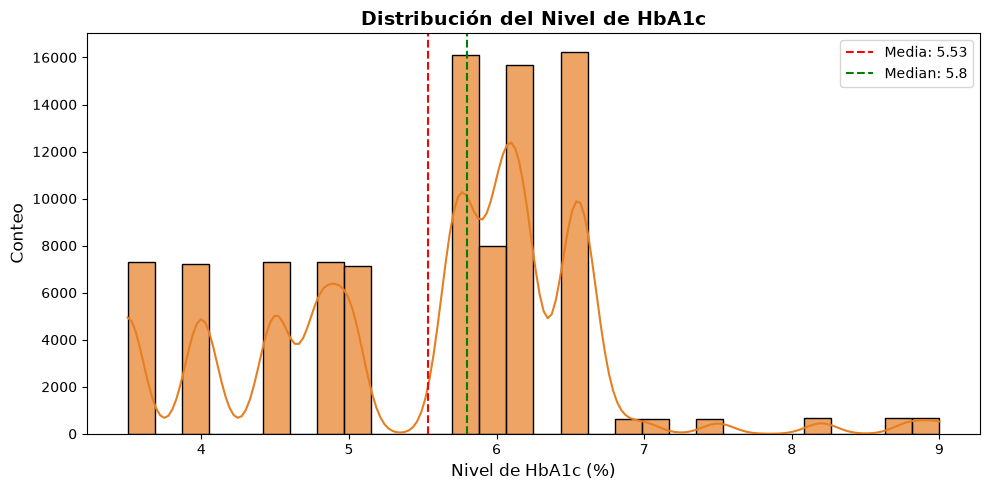

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=diabetes, x='HbA1c_level', bins=30, kde=True, color='#e67e22', edgecolor='black', alpha=0.7, ax=ax)
ax.set_title('Distribución del Nivel de HbA1c', fontsize=14, fontweight='bold')
ax.set_xlabel('Nivel de HbA1c (%)', fontsize=12)
ax.set_ylabel('Conteo', fontsize=12)
ax.axvline(diabetes['HbA1c_level'].mean(), color='red', linestyle='--', label=f'Media: {diabetes["HbA1c_level"].mean():.2f}')
ax.axvline(diabetes['HbA1c_level'].median(), color='green', linestyle='--', label=f'Median: {diabetes["HbA1c_level"].median():.1f}')
ax.legend()
plt.tight_layout()

In [23]:
print(f'Asimetría de la distribución de la hemoglobina: {diabetes["HbA1c_level"].skew():.2f}')

Asimetría de la distribución de la hemoglobina: -0.05


**HbA1c_level:** hemoglobina glucosilada entre 3.5% y 9%, con mediana 5.8% y distribución casi simétrica. Como el umbral diagnóstico de diabetes es 6.5%, la cola derecha corresponde a los registros con valores compatibles con la enfermedad.

blood_glucose_level: 2031 outliers (2.11%)


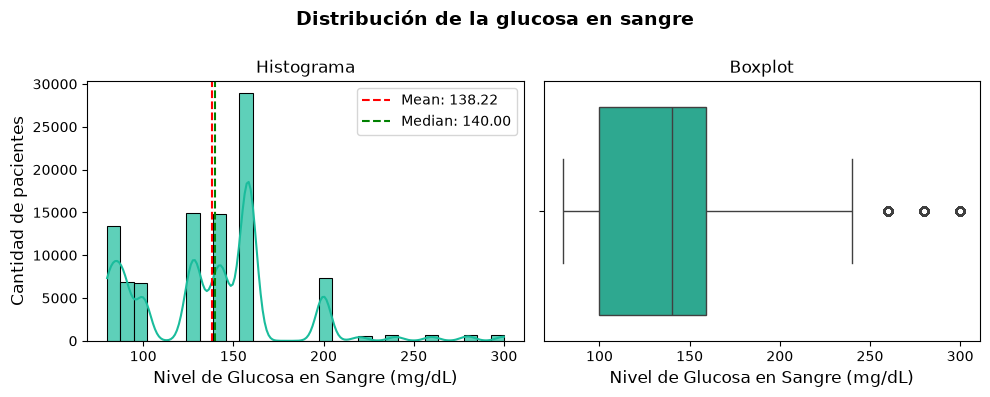

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Distribución de la glucosa en sangre', fontsize=14, fontweight='bold')

sns.histplot(data=diabetes, x='blood_glucose_level', bins=30, kde=True, color='#1abc9c', edgecolor='black', alpha=0.7, ax=axes[0])
axes[0].set_xlabel('Nivel de Glucosa en Sangre (mg/dL)', fontsize=12)
axes[0].set_ylabel('Cantidad de pacientes', fontsize=12)
axes[0].axvline(diabetes['blood_glucose_level'].mean(), color='red', linestyle='--', label=f'Mean: {diabetes["blood_glucose_level"].mean():.2f}')
axes[0].axvline(diabetes['blood_glucose_level'].median(), color='green', linestyle='--', label=f'Median: {diabetes["blood_glucose_level"].median():.2f}')
axes[0].legend()
axes[0].set_title("Histograma")

sns.boxplot(x=diabetes["blood_glucose_level"], ax=axes[1], color='#1abc9c')
axes[1].set_xlabel('Nivel de Glucosa en Sangre (mg/dL)', fontsize=12)
axes[1].set_title("Boxplot")

# Reporte de outlier
Q1 = diabetes['blood_glucose_level'].quantile(0.25)
Q3 = diabetes['blood_glucose_level'].quantile(0.75)
IQR = Q3 - Q1
outliers = ((diabetes['blood_glucose_level'] < Q1 - 1.5 * IQR) | (diabetes['blood_glucose_level'] > Q3 + 1.5 * IQR)).sum()
print(f'blood_glucose_level: {outliers} outliers ({outliers/len(diabetes)*100:.2f}%)')

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

In [24]:
print(f'Asimetría de la distribución de la glucosa en sangre: {diabetes["blood_glucose_level"].skew():.2f}')

Asimetría de la distribución de la glucosa en sangre: 0.84


**Glucosa en sangre:** mediana de 140 mg/dL (rango 80–300) con asimetría derecha moderada (skew ≈ 0.8). Los atípicos del boxplot corresponden a hiperglucemia (>200 mg/dL), típicamente asociada a diabetes; los picos del histograma reflejan que los niveles se registran en valores discretos.

## Gráficos bi-variables

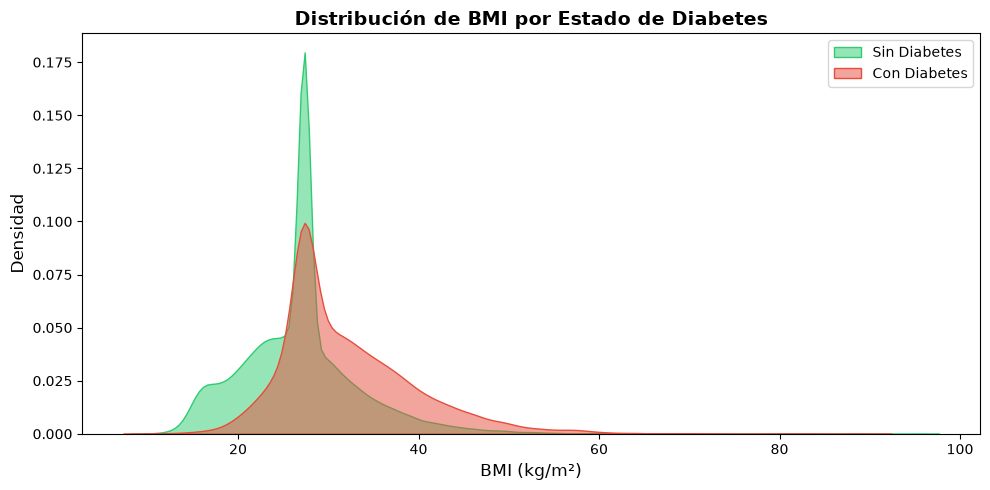

In [33]:
fig, ax = plt.subplots(figsize=(10, 5))
for label, color in zip([0, 1], ['#2ecc71', '#e74c3c']):
    subset = diabetes[diabetes['diabetes'] == label]
    sns.kdeplot(data=subset, x='bmi', fill=True, alpha=0.5, color=color, 
                label=f'Diabetes = {label}', ax=ax)
ax.set_title('Distribución de BMI por Estado de Diabetes', fontsize=14, fontweight='bold')
ax.set_xlabel('BMI (kg/m²)', fontsize=12)
ax.set_ylabel('Densidad', fontsize=12)
ax.legend(['Sin Diabetes', 'Con Diabetes'])
plt.tight_layout()

plt.show()

In [34]:
diabetes.groupby("diabetes")["bmi"].median()

diabetes
0    27.320
1    29.985
Name: bmi, dtype: float64

**IMC según diabetes:** los registros con diabetes (1) muestran una mediana de IMC claramente mayor (~30 vs ~27.3). La distribución del grupo positivo está desplazada hacia arriba y su caja es más amplia, coherente con el sobrepeso/obesidad como factor de riesgo. Hay solapamiento importante entre grupos, por lo que un IMC alto no basta por sí solo para discriminar.

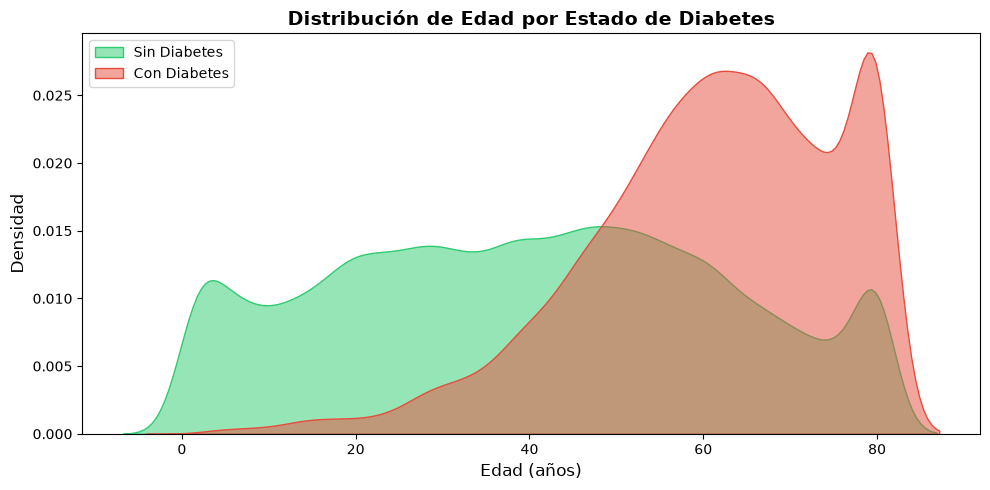

In [32]:
fig, ax = plt.subplots(figsize=(10, 5))
for label, color in zip([0, 1], ['#2ecc71', '#e74c3c']):
    subset = diabetes[diabetes['diabetes'] == label]
    sns.kdeplot(data=subset, x='age', fill=True, alpha=0.5, color=color, 
                label=f'Diabetes = {label}', ax=ax)
ax.set_title('Distribución de Edad por Estado de Diabetes', fontsize=14, fontweight='bold')
ax.set_xlabel('Edad (años)', fontsize=12)
ax.set_ylabel('Densidad', fontsize=12)
ax.legend(['Sin Diabetes', 'Con Diabetes'])
plt.tight_layout()

plt.show()

In [35]:
diabetes.groupby("diabetes")["age"].median()

diabetes
0    40.0
1    62.0
Name: age, dtype: float64

**Edad según diabetes:** el efecto es aún más marcado que en el IMC: la mediana de edad pasa de ~40 años en no diabéticos a ~62 años en diabéticos, con cajas casi sin solapamiento en el rango intercuartílico. Podríamos considerar la edad como uno de los predictores más fuertes del dataset.

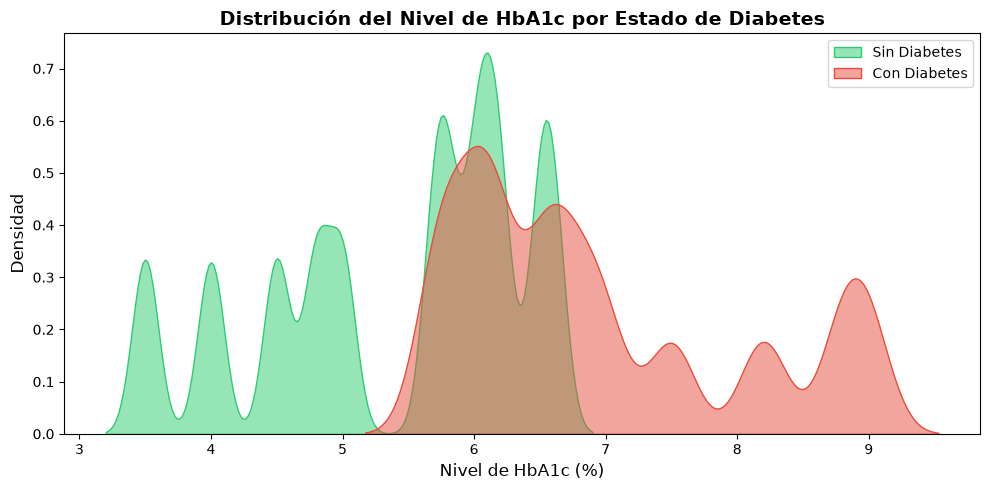

In [37]:
fig, ax = plt.subplots(figsize=(10, 5))
for label, color in zip([0, 1], ['#2ecc71', '#e74c3c']):
    subset = diabetes[diabetes['diabetes'] == label]
    sns.kdeplot(data=subset, x='HbA1c_level', fill=True, alpha=0.5, color=color, 
                label=f'Diabetes = {label}', ax=ax)
ax.set_title('Distribución del Nivel de HbA1c por Estado de Diabetes', fontsize=14, fontweight='bold')
ax.set_xlabel('Nivel de HbA1c (%)', fontsize=12)
ax.set_ylabel('Densidad', fontsize=12)
ax.legend(['Sin Diabetes', 'Con Diabetes'])
plt.tight_layout()

plt.show()

In [38]:
print('=== HbA1c por Estado de Diabetes ===')
print()
print('Estadísticas por grupo:')
print(diabetes.groupby('diabetes')['HbA1c_level'].describe().round(2))
print()

# Percentiles
for label, name in [(0, 'Sin diabetes'), (1, 'Con diabetes')]:
    subset = diabetes[diabetes['diabetes'] == label]['HbA1c_level']
    print(f'{name}:')
    print(f'  Media: {subset.mean():.2f}%')
    print(f'  Mediana: {subset.median():.2f}%')
    print(f'  P10: {subset.quantile(0.1):.2f}% | P90: {subset.quantile(0.9):.2f}%')
    print()

# Overlap analysis
no_diab = diabetes[diabetes['diabetes'] == 0]['HbA1c_level']
diab = diabetes[diabetes['diabetes'] == 1]['HbA1c_level']
print(f'Rango sin diabetes: {no_diab.min():.1f} - {no_diab.max():.1f}')
print(f'Rango con diabetes: {diab.min():.1f} - {diab.max():.1f}')
print(f'Solapamiento mínimo: {max(no_diab.min(), diab.min()):.1f} - {min(no_diab.max(), diab.max()):.1f}')


=== HbA1c por Estado de Diabetes ===

Estadísticas por grupo:
            count  mean   std  min  25%  50%  75%  max
diabetes                                              
0         87664.0  5.40  0.97  3.5  4.8  5.8  6.2  6.6
1          8482.0  6.93  1.08  5.7  6.1  6.6  7.5  9.0

Sin diabetes:
  Media: 5.40%
  Mediana: 5.80%
  P10: 4.00% | P90: 6.50%

Con diabetes:
  Media: 6.93%
  Mediana: 6.60%
  P10: 5.80% | P90: 8.80%

Rango sin diabetes: 3.5 - 6.6
Rango con diabetes: 5.7 - 9.0
Solapamiento mínimo: 5.7 - 6.6


**HbA1c por estado de diabetes:** El gráfico muestra una separación clara entre ambos grupos. Los pacientes sin diabetes tienen una distribución concentrada entre 4.8% y 6.2% (media: 5.40%), mientras que los con diabetes se agrupan entre 6.1% y 7.5% (media: 6.93%), con un corrimiento evidente hacia la derecha. Existe una zona de solapamiento entre 5.7% y 6.6%, donde la distinción es ambigua. Esto confirma que HbA1c es también uno de los predictores más fuertes del modelo, ya que separa eficazmente ambos grupos.

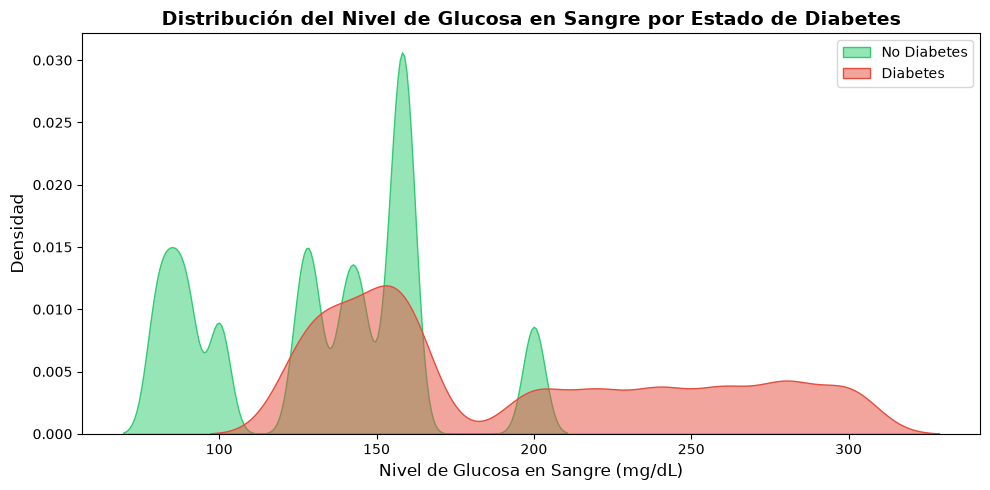

In [39]:
fig, ax = plt.subplots(figsize=(10, 5))
for label, color in zip([0, 1], ['#2ecc71', '#e74c3c']):
    subset = diabetes[diabetes['diabetes'] == label]
    sns.kdeplot(data=subset, x='blood_glucose_level', fill=True, alpha=0.5, color=color, 
                label=f'Diabetes = {label}', ax=ax)
ax.set_title('Distribución del Nivel de Glucosa en Sangre por Estado de Diabetes', fontsize=14, fontweight='bold')
ax.set_xlabel('Nivel de Glucosa en Sangre (mg/dL)', fontsize=12)
ax.set_ylabel('Densidad', fontsize=12)
ax.legend(['No Diabetes', 'Diabetes'])
plt.tight_layout()

plt.show()

In [69]:
print(f'Correlación entre nivel de glucosa en sangre y diabetes: {diabetes["blood_glucose_level"].corr(diabetes["diabetes"]):.2f}')

Correlación entre nivel de glucosa en sangre y diabetes: 0.42


**Nivel de glucosa por estado de diabetes:** El gráfico revela una marcada separación entre ambos grupos. Los pacientes sin diabetes se concentran entre 80 y 150 mg/dL (media: 132.9), mientras que los diabéticos se distribuyen entre 140 y 300 mg/dL (media: 194.1), con un pico hacia valores más altos. A diferencia de HbA1c, el solapamiento es menor, lo que indica que la glucosa en sangre es un diferenciador más nítido. Esto es consistente con su correlación de 0.42 con la variable objetivo.

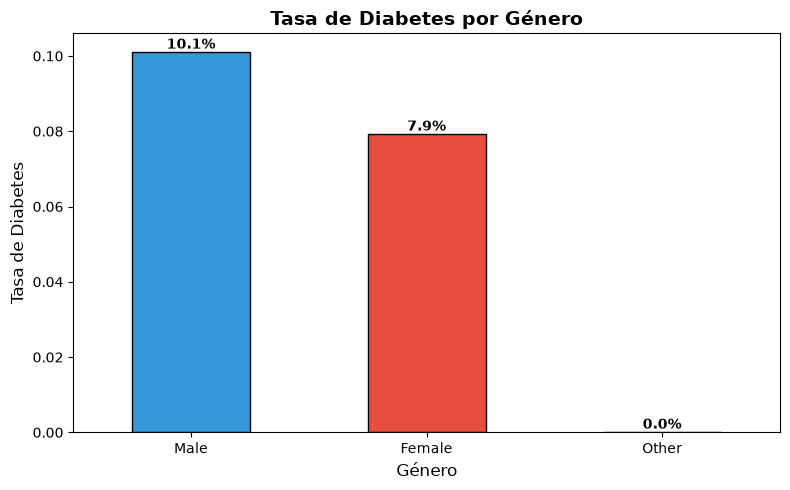

In [46]:
fig, ax = plt.subplots(figsize=(8, 5))
gender_diabetes = diabetes.groupby('gender')['diabetes'].mean().sort_values(ascending=False)
colors = ['#3498db', '#e74c3c', '#95a5a6']
gender_diabetes.plot(kind='bar', color=colors[:len(gender_diabetes)], edgecolor='black', ax=ax)
ax.set_title('Tasa de Diabetes por Género', fontsize=14, fontweight='bold')
ax.set_xlabel('Género', fontsize=12)
ax.set_ylabel('Tasa de Diabetes', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for i, v in enumerate(gender_diabetes.values):
    ax.text(i, v + 0.001, f'{v:.1%}', ha='center', fontweight='bold')
plt.tight_layout()

plt.show()

**Tasa de diabetes por Género:** Las mujeres muestran una tasa de diabetes del 7.6%, mientras que los hombres presentan 9.8%. La diferencia es moderada pero observable. El género aparece como un predictor débil (correlación: 0.04), lo que sugiere que factores clínicos como HbA1c y glucosa son mucho más determinantes que el sexo biológico en la predicción de diabetes.

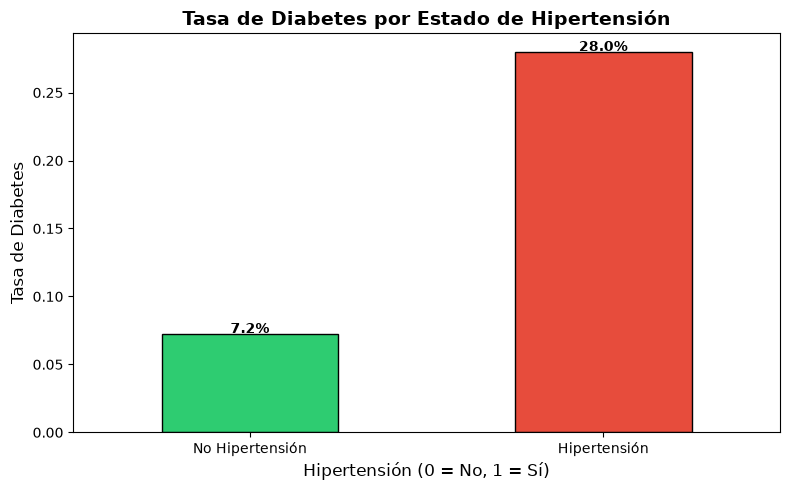

In [47]:
fig, ax = plt.subplots(figsize=(8, 5))
hyper_diabetes = diabetes.groupby('hypertension')['diabetes'].mean()
colors = ['#2ecc71', '#e74c3c']
hyper_diabetes.plot(kind='bar', color=colors, edgecolor='black', ax=ax)
ax.set_title('Tasa de Diabetes por Estado de Hipertensión', fontsize=14, fontweight='bold')
ax.set_xlabel('Hipertensión (0 = No, 1 = Sí)', fontsize=12)
ax.set_ylabel('Tasa de Diabetes', fontsize=12)
ax.set_xticklabels(['No Hipertensión', 'Hipertensión'], rotation=0)
for i, v in enumerate(hyper_diabetes.values):
    ax.text(i, v + 0.001, f'{v:.1%}', ha='center', fontweight='bold')
plt.tight_layout()

plt.show()

**Tasa de diabetes por hipertensión:** Podemos ver que pacientes sin hipertensión tienen una tasa del 6.9%, mientras que los hipertensos alcanzan el 27.9%, es decir, 4 veces más alta. La hipertensión es un factor de riesgo cardiovascular importante y su correlación de 0.20 con diabetes confirma su relevancia como predictor moderado en el modelo.

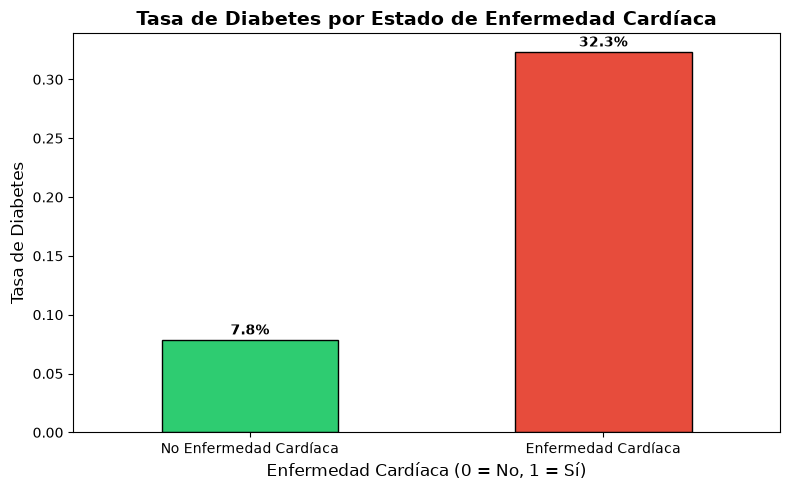

In [48]:
fig, ax = plt.subplots(figsize=(8, 5))
heart_diabetes = diabetes.groupby('heart_disease')['diabetes'].mean()
colors = ['#2ecc71', '#e74c3c']
heart_diabetes.plot(kind='bar', color=colors, edgecolor='black', ax=ax)
ax.set_title('Tasa de Diabetes por Estado de Enfermedad Cardíaca', fontsize=14, fontweight='bold')
ax.set_xlabel('Enfermedad Cardíaca (0 = No, 1 = Sí)', fontsize=12)
ax.set_ylabel('Tasa de Diabetes', fontsize=12)
ax.set_xticklabels(['No Enfermedad Cardíaca', 'Enfermedad Cardíaca'], rotation=0)
for i, v in enumerate(heart_diabetes.values):
    ax.text(i, v + 0.005, f'{v:.1%}', ha='center', fontweight='bold')
plt.tight_layout()

plt.show()

**Tasa de Diabetes por Enfermedad Cardíaca:** El contraste es aún más marcado que con hipertensión: sin enfermedad cardíaca la tasa es 7.5%, con ella sube a 32.1%, más de 4 veces superior. Aunque solo el 3.9% de los pacientes tiene enfermedad cardíaca, este subgrupo concentra una parte desproporcionada de casos diabéticos (correlación: 0.17).

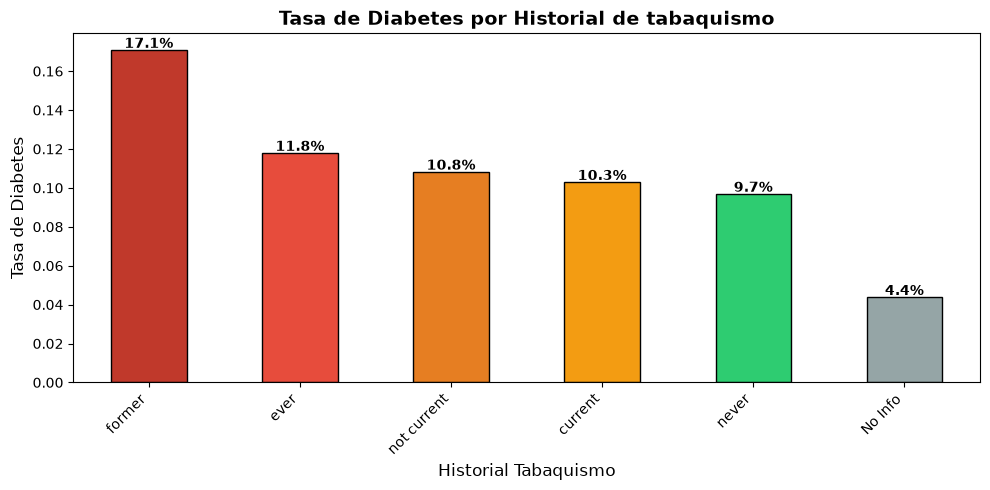

In [66]:
fig, ax = plt.subplots(figsize=(10, 5))
smoking_diabetes = diabetes.groupby('smoking_history')['diabetes'].mean().sort_values(ascending=False)
colors = ['#c0392b', '#e74c3c', '#e67e22', '#f39c12', '#2ecc71', '#95a5a6']
smoking_diabetes.plot(kind='bar', color=colors[:len(smoking_diabetes)], edgecolor='black', ax=ax)
ax.set_title('Tasa de Diabetes por Historial de tabaquismo', fontsize=14, fontweight='bold')
ax.set_xlabel('Historial Tabaquismo', fontsize=12)
ax.set_ylabel('Tasa de Diabetes', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
for i, v in enumerate(smoking_diabetes.values):
    ax.text(i, v + 0.001, f'{v:.1%}', ha='center', fontweight='bold')
plt.tight_layout()

plt.show()

**Tasa de Diabetes por Historial de tabaquismo:** Los resultados son más matizados de lo esperado. Los pacientes con historial de "former" (ex-fumadores) muestran la tasa más alta (17.0%), seguidos por "ever" (11.8%) y "not current" (10.7%). Los "never" (nunca fumaron) están en 9.5%. La categoría "No Info" tiene la tasa más baja (4.1%), lo que sugiere que estos registros pueden representar pacientes con menos datos clínicos disponibles. El tabaquismo es un predictor débil (correlación: 0.08), posiblemente porque la información es ruidosa.

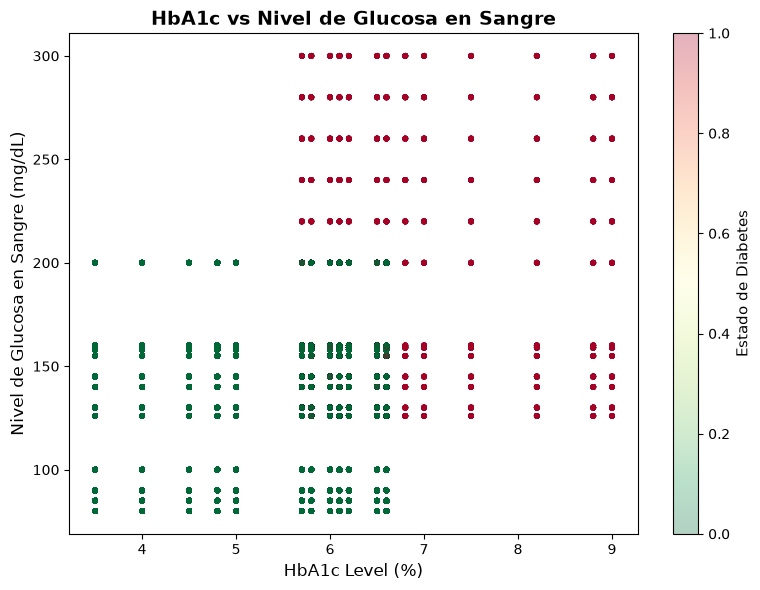

In [52]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(diabetes['HbA1c_level'], diabetes['blood_glucose_level'], 
                     c=diabetes['diabetes'], cmap='RdYlGn_r', alpha=0.3, s=10)
ax.set_title('HbA1c vs Nivel de Glucosa en Sangre', fontsize=14, fontweight='bold')
ax.set_xlabel('HbA1c Level (%)', fontsize=12)
ax.set_ylabel('Nivel de Glucosa en Sangre (mg/dL)', fontsize=12)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Estado de Diabetes', fontsize=11)
plt.tight_layout()

plt.show()

**HbA1c vs Nivel de Glucosa en Sangre:** El gráfico de dispersión muestra una agrupación clara: los puntos rojos (diabéticos) se concentran en la esquina superior derecha (HbA1c > 6.5%, glucosa > 150 mg/dL), mientras que los verdes (no diabéticos) dominan la esquina inferior izquierda. Se observa una correlación positiva entre ambas variables (ambas miden aspectos del metabolismo de la glucosa), lo cual es esperado clínicamente. Esta superposición refuerza por qué el modelo puede usar ambas variables para separar clases.

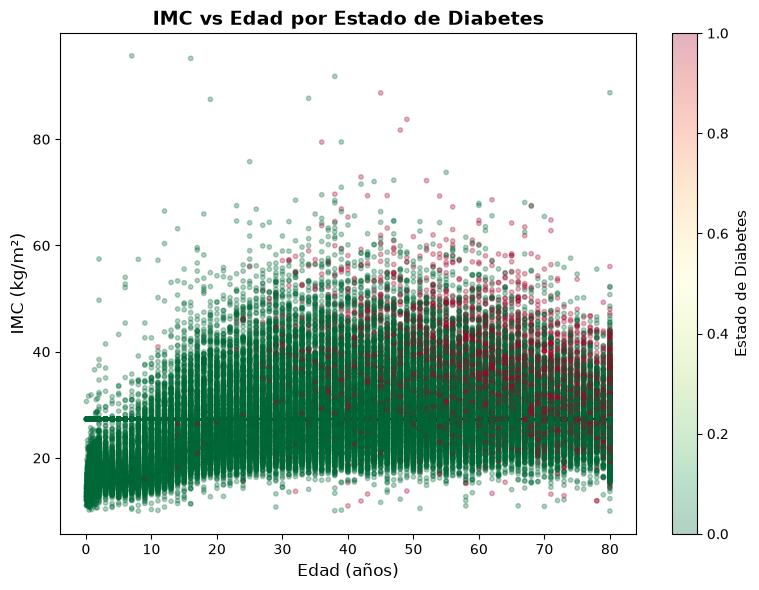

In [54]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(diabetes['age'], diabetes['bmi'], 
                     c=diabetes['diabetes'], cmap='RdYlGn_r', alpha=0.3, s=10)
ax.set_title('IMC vs Edad por Estado de Diabetes', fontsize=14, fontweight='bold')
ax.set_xlabel('Edad (años)', fontsize=12)
ax.set_ylabel('IMC (kg/m²)', fontsize=12)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Estado de Diabetes', fontsize=11)
plt.tight_layout()

plt.show()

**IMC vs Edad por Estado de Diabetes:** Se observa que los casos diabéticos (rojos) se acumulan en la zona de mayor edad (>50 años) y mayorBMI (>30 kg/m²). No hay una relación lineal clara entre BMI y edad, sí hay una concentración de diabetes en pacientes de edad avanzada con sobrepeso u obesidad. Pacientes jóvenes con BMI normal muestran muy pocos casos de diabetes.

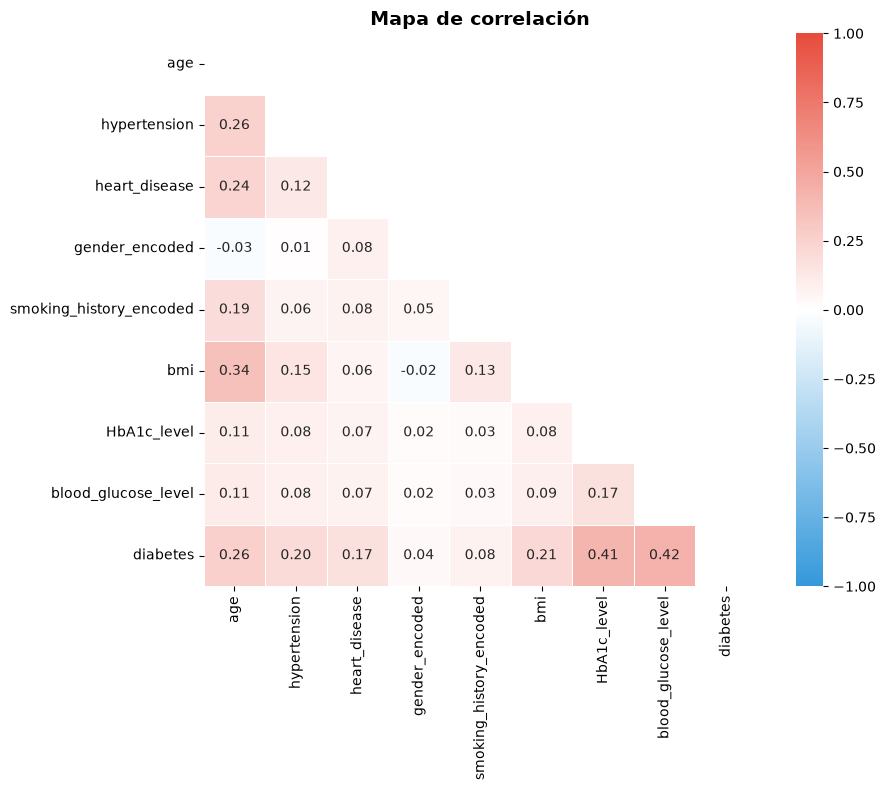


Correlación con target:
blood_glucose_level        0.424336
HbA1c_level                0.406408
age                        0.264927
bmi                        0.214932
hypertension               0.195710
heart_disease              0.170711
smoking_history_encoded    0.077245
gender_encoded             0.037613
Name: diabetes, dtype: float64


In [62]:
fig, ax = plt.subplots(figsize=(10, 8))
# Creación de mapeo ordinal para smoking_history
smoking_map = {'never': 1, 'No Info': 1, 'not current': 2, 'former': 3, 'current': 4, 'ever': 5}
diabetes_corr = diabetes.copy()
diabetes_corr['smoking_history_encoded'] = diabetes_corr['smoking_history'].map(smoking_map)

# Creación de dummy para gender (Female=0, Male=1, Other=2)
diabetes_corr['gender_encoded'] = diabetes_corr['gender'].map({'Female': 0, 'Male': 1, 'Other': 2})

corr_cols = ['age', 'hypertension', 'heart_disease', 'gender_encoded', 
             'smoking_history_encoded', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']
corr_matrix = diabetes_corr[corr_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = LinearSegmentedColormap.from_list('custom', ['#3498db', 'white', '#e74c3c'])
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap=cmap, center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Mapa de correlación', fontsize=14, fontweight='bold')
plt.tight_layout()

plt.show()

print('\nCorrelación con target:')
print(corr_matrix['diabetes'].drop('diabetes').sort_values(ascending=False))

El mapa de correlación confirma numéricamente lo observado en los gráficos: las variables con mayor correlación con diabetes son blood_glucose_level (0.42) y HbA1c_level (0.40), seguidas por age (0.26), bmi (0.21), hypertension (0.20) y heart_disease (0.17). Gender (0.04) y smoking_history (0.08) tienen correlaciones débiles. No se observan correlaciones altas entre predictores que sugieran multicolinealidad problemática.

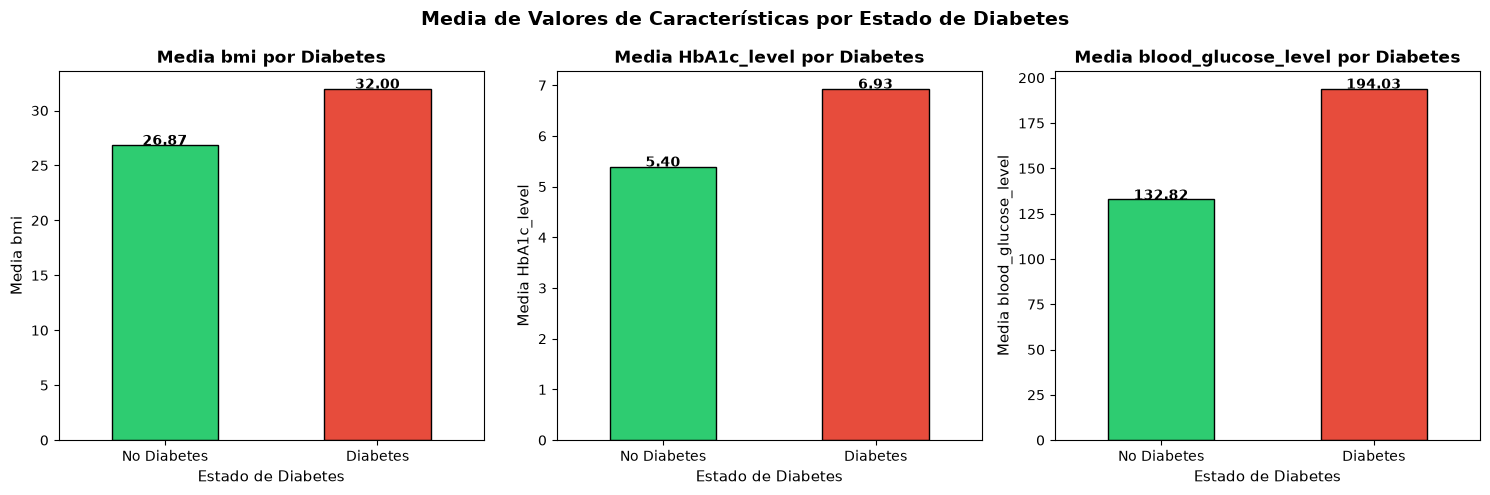

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

features_to_compare = ['bmi', 'HbA1c_level', 'blood_glucose_level']
for idx, col in enumerate(features_to_compare):
    means = diabetes.groupby('diabetes')[col].mean()
    colors = ['#2ecc71', '#e74c3c']
    means.plot(kind='bar', color=colors, edgecolor='black', ax=axes[idx])
    axes[idx].set_title(f'Media {col} por Diabetes', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Estado de Diabetes', fontsize=11)
    axes[idx].set_ylabel(f'Media {col}', fontsize=11)
    axes[idx].set_xticklabels(['No Diabetes', 'Diabetes'], rotation=0)
    for i, v in enumerate(means.values):
        axes[idx].text(i, v, f'{v:.2f}', ha='center', fontweight='bold')

plt.suptitle('Media de Valores de Características por Estado de Diabetes', fontsize=14, fontweight='bold')
plt.tight_layout()

plt.show()

**Media de variables clave por estado de diabetes:** La comparación directa confirma los hallazgos: los diabéticos tienen unBMI promedio de 32.0 vs 26.9, HbA1c de 6.93% vs 5.40%, y glucosa de 194.1 vs 132.9 mg/dL. Las diferencias son estadísticamente relevantes y clínicamente significativas, especialmente en HbA1c y glucosa, que muestran las mayores diferencias relativas.

In [ ]:
print('=== Estadísticas del Dataset ===')
print(f'Total pacientes: {len(diabetes):,}')
print(f'Diabetic pacientes: {(diabetes["diabetes"] == 1).sum():,} ({diabetes["diabetes"].mean()*100:.1f}%)')
print(f'Non-diabetic pacientes: {(diabetes["diabetes"] == 0).sum():,} ({(1-diabetes["diabetes"]).mean()*100:.1f}%)')
print(f'\nAge range: {diabetes["age"].min():.0f} - {diabetes["age"].max():.0f} years')
print(f'BMI range: {diabetes["bmi"].min():.1f} - {diabetes["bmi"].max():.1f} kg/m²')
print(f'HbA1c range: {diabetes["HbA1c_level"].min():.1f} - {diabetes["HbA1c_level"].max():.1f} %')
print(f'Glucose range: {diabetes["blood_glucose_level"].min():.0f} - {diabetes["blood_glucose_level"].max():.0f} mg/dL')

=== Estadísticas del Dataset ===
Total patients: 96,146
Diabetic patients: 8,482 (8.8%)
Non-diabetic patients: 87,664 (91.2%)

Age range: 0 - 80 years
BMI range: 10.0 - 95.7 kg/m²
HbA1c range: 3.5 - 9.0 %
Glucose range: 80 - 300 mg/dL


## Resumen de Hallazgos
### Problemas de Calidad de Datos
1. **Sin valores faltantes** en el conjunto de datos
2. **Filas duplicadas** detectadas (manejar en preprocesamiento)
3. **Categoría "No Info"** en smoking_history (~35% de los datos) - requiere tratamiento
4. **Valores atípicos** detectados en BMI y otras variables numéricas
5. **Desequilibrio de clases**: Solo ~8.5% de los pacientes tienen diabetes

### Principales Factores de Riesgo de Diabetes Identificados
1. **HbA1c_level** - Correlación más fuerte con diabetes (valores más altos = mayor riesgo)
2. **blood_glucose_level** - Correlación positiva fuerte con diabetes
3. **age** - Pacientes mayores tienen tasas significativamente más altas de diabetes
4. **bmi** - Mayor BMI asociado con mayor riesgo de diabetes
5. **hypertension** - Pacientes con hipertensión muestran ~2 veces mayor tasa de diabetes
6. **heart_disease** - Pacientes con enfermedad cardíaca muestran ~2 veces mayor tasa de diabetes

## Características Candidatas para Modelado
- **age** - continua, predictor fuerte
- **bmi** - continua, predictor moderado
- **HbA1c_level** - continua, predictor muy fuerte
- **blood_glucose_level** - continua, predictor muy fuerte
- **hypertension** - binaria, predictor moderado
- **heart_disease** - binaria, predictor moderado
- **gender** - categórica nominal, predictor débil
- **smoking_history** - categórica ordinal, predictor débil

## Decisiones de Ingeniería de Características
1. **smoking_history**:
    - Mapeo ordinal: never(1) → not current(2) → former(3) → current(4) → ever(5)
    - "No Info" tratado como 'never' (1) o imputado por separado
    - Alternativa: codificación one-hot con N-1 dummies

2. **gender**:
    - Categórica nominal - usar codificación one-hot

3. **Valores atípicos en BMI**:
    - Considerar limitar al percentil 99 o usar robust scaling

4. **Desequilibrio de clases**:
    - Considerar SMOTE, pesos de clase o selección de umbral apropiada

5. **Posible fuga de datos**:
    - HbA1c_level y blood_glucose_level son mediciones clínicas directamente relacionadas con el diagnóstico de diabetes
    - Son predictores válidos pero deben señalarse como mediciones posteriores en la interpretación